In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

RANDOM_STATE = 42

In [11]:
# Load the dataset.
df_raw = pd.read_csv("Telco-Customer-Churn.csv")

# Quick sanity checks.
print(f"Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")
df_raw.head()

Rows: 7043, Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
# Review schema and key data quality metrics before preprocessing.
df_raw.info()
print("\nMissing values (top 10):")
print(df_raw.isna().sum().sort_values(ascending=False).head(10))
print(f"\nDuplicate rows: {df_raw.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
# Create a working copy so the raw data remains unchanged.
df = df_raw.copy()

# Remove duplicate customer records, if any.
df = df.drop_duplicates()

# Strip whitespace from object columns to prevent hidden category mismatches.
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    df[col] = df[col].astype(str).str.strip()

# Convert TotalCharges to numeric and impute invalid/missing values with median.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop identifier column because it does not carry predictive signal.
df = df.drop(columns=['customerID'])

print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (7043, 20)


In [14]:
# Encode target label as binary values: Yes -> 1, No -> 0.
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode categorical columns. drop_first avoids multicollinearity.
df_model = pd.get_dummies(df, drop_first=True)

# Split features and target.
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print(f"Feature matrix shape before reduction: {X.shape}")

Feature matrix shape before reduction: (7043, 30)


In [15]:
# Split data with stratification to preserve churn class ratio.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Standardize features for logistic regression stability.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dimensionality reduction: select top-k informative features.
k = min(25, X_train.shape[1])
selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_feature_names = X.columns[selector.get_support()]
print(f"Original features: {X.shape[1]}")
print(f"Selected features: {len(selected_feature_names)}")

Original features: 30
Selected features: 25


In [16]:
# Validate nulls after preprocessing and view selected features.
print("Remaining null count in model dataframe:", int(df_model.isnull().sum().sum()))

print("\nSelected Features (first 15):")
print(pd.Series(selected_feature_names).head(15).to_string(index=False))

Remaining null count in model dataframe: 0

Selected Features (first 15):
                       SeniorCitizen
                              tenure
                      MonthlyCharges
                        TotalCharges
                      Dependents_Yes
                    PhoneService_Yes
      MultipleLines_No phone service
         InternetService_Fiber optic
                  InternetService_No
  OnlineSecurity_No internet service
                  OnlineSecurity_Yes
    OnlineBackup_No internet service
                    OnlineBackup_Yes
DeviceProtection_No internet service
                DeviceProtection_Yes


In [17]:
# Train logistic regression with class balancing for imbalanced labels.
model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
model.fit(X_train_selected, y_train)

print("Model training completed")

Model training completed


Accuracy: 0.7359829666430092

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



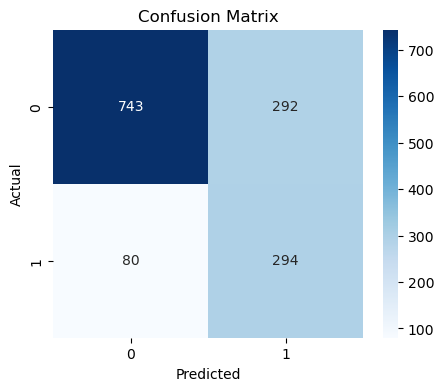

AUC Score: 0.8424681598594642


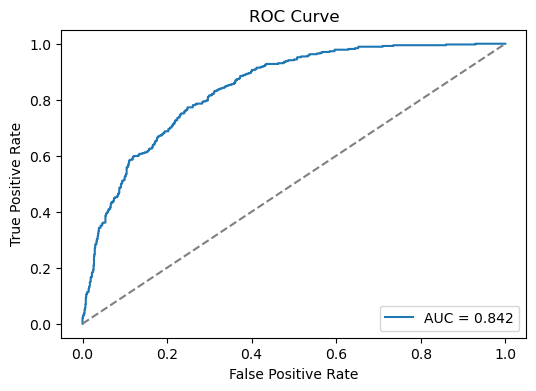


Top Features Influencing Churn:

                                  Feature  Coefficient
2                          MonthlyCharges     0.682525
3                            TotalCharges     0.496036
23         PaymentMethod_Electronic check     0.190573
21                   PaperlessBilling_Yes     0.168424
6          MultipleLines_No phone service     0.140318
7             InternetService_Fiber optic     0.112636
0                           SeniorCitizen     0.058656
24             PaymentMethod_Mailed check     0.018803
22  PaymentMethod_Credit card (automatic)    -0.001915
8                      InternetService_No    -0.015635

Bottom Features (strongest negative coefficients):

                            Feature  Coefficient
17  StreamingTV_No internet service    -0.015635
14             DeviceProtection_Yes    -0.074637
4                    Dependents_Yes    -0.100186
12                 OnlineBackup_Yes    -0.131851
5                  PhoneService_Yes    -0.140318
16            

In [18]:
# Generate class predictions and positive-class probabilities.
y_pred = model.predict(X_test_selected)
y_prob = model.predict_proba(X_test_selected)[:, 1]

# Compute and print core classification metrics.
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Build and display confusion matrix.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot ROC curve and calculate AUC.
roc_auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", roc_auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

# Show selected features with strongest positive churn contribution.
coefficients = pd.DataFrame({
    'Feature': selected_feature_names,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nTop Features Influencing Churn:\n")
print(coefficients.head(10))

print("\nBottom Features (strongest negative coefficients):\n")
print(coefficients.tail(10))

# Print final summary metrics.
print("\nFinal Model Performance:")
print("Accuracy:", accuracy)
print("AUC Score:", roc_auc)